In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

In [2]:
# =========================
# PATHS
# =========================
TRAIN_PATH_1 = "segment_alerts_all_airports_train.csv"
TEST_PATH = "dataset_set.csv"             # adapte au vrai nom du fichier test

# =========================
# LOAD
# =========================
df_train = pd.read_csv(TRAIN_PATH_1)

df_test = pd.read_csv(TEST_PATH)

for df_ in [df_train, df_test]:
    if "Unnamed: 0" in df_.columns:
        df_.drop(columns=["Unnamed: 0"], inplace=True, errors="ignore")
    df_["date"] = pd.to_datetime(df_["date"], utc=True)
    df_["icloud"] = df_["icloud"].astype(bool)

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

print("\nTrain years:")
print(df_train["date"].dt.year.value_counts().sort_index())

print("\nTest years:")
print(df_test["date"].dt.year.value_counts().sort_index())

print("\nTrain columns:")
print(sorted(df_train.columns.tolist()))

print("\nTest columns:")
print(sorted(df_test.columns.tolist()))

Train shape: (507071, 13)
Test shape : (183945, 13)

Train years:
date
2016    105074
2017     58983
2018    116033
2019     55300
2020     55680
2021     38300
2022     77701
Name: count, dtype: int64

Test years:
date
2023    51086
2024    47451
2025    85408
Name: count, dtype: int64

Train columns:
['airport', 'airport_alert_id', 'amplitude', 'azimuth', 'date', 'dist', 'icloud', 'is_last_lightning_cloud_ground', 'lat', 'lightning_airport_id', 'lightning_id', 'lon', 'maxis']

Test columns:
['airport', 'airport_alert_id', 'amplitude', 'azimuth', 'date', 'dist', 'icloud', 'is_last_lightning_cloud_ground', 'lat', 'lightning_airport_id', 'lightning_id', 'lon', 'maxis']


In [3]:
def month_to_season(m):
    if m in [12, 1, 2]:
        return "winter"
    elif m in [3, 4, 5]:
        return "spring"
    elif m in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"


def add_base_columns(df, strong_cg_threshold=None):
    df = df.copy()

    df["is_cg"] = (~df["icloud"]).astype("int8")
    df["is_ic"] = df["icloud"].astype("int8")

    df["is_0_3"] = (df["dist"] < 3).astype("int8")
    df["is_3_10"] = ((df["dist"] >= 3) & (df["dist"] < 10)).astype("int8")
    df["is_10_20"] = ((df["dist"] >= 10) & (df["dist"] < 20)).astype("int8")
    df["is_20_30"] = ((df["dist"] >= 20) & (df["dist"] < 30)).astype("int8")

    df["amp_abs"] = df["amplitude"].abs()

    if strong_cg_threshold is None:
        strong_cg_threshold = df.loc[df["is_cg"] == 1, "amp_abs"].quantile(0.90)

    df["is_strong_cg"] = ((df["is_cg"] == 1) & (df["amp_abs"] >= strong_cg_threshold)).astype("int8")

    df["hour"] = df["date"].dt.hour
    df["month"] = df["date"].dt.month
    df["dayofyear"] = df["date"].dt.dayofyear
    df["weekday"] = df["date"].dt.weekday

    df["season"] = df["month"].apply(month_to_season)
    df["is_summer"] = (df["season"] == "summer").astype("int8")
    df["is_peak_hour"] = df["hour"].between(12, 18).astype("int8")

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    az_rad = np.deg2rad(df["azimuth"])
    df["azimuth_sin"] = np.sin(az_rad)
    df["azimuth_cos"] = np.cos(az_rad)

    az_bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
    az_labels = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    df["az_sector"] = pd.cut(
        df["azimuth"].mod(360),
        bins=az_bins,
        labels=az_labels,
        include_lowest=True,
        right=False
    )

    df["cg_amp_abs"] = np.where(df["is_cg"] == 1, df["amp_abs"], np.nan)

    return df, strong_cg_threshold


def build_timestamp_features(df_all):
    t0 = time.time()

    base = (
        df_all.groupby(["airport", "date"], as_index=False)
              .agg(
                  n_total=("lightning_id", "size"),
                  n_cg=("is_cg", "sum"),
                  n_ic=("is_ic", "sum"),
                  n_strong_cg=("is_strong_cg", "sum"),

                  n_0_3=("is_0_3", "sum"),
                  n_3_10=("is_3_10", "sum"),
                  n_10_20=("is_10_20", "sum"),
                  n_20_30=("is_20_30", "sum"),

                  dist_min=("dist", "min"),
                  dist_mean=("dist", "mean"),
                  dist_max=("dist", "max"),

                  amp_abs_mean=("amp_abs", "mean"),
                  amp_abs_max=("amp_abs", "max"),
                  amp_abs_sum=("amp_abs", "sum"),

                  cg_amp_abs_mean=("cg_amp_abs", "mean"),
                  cg_amp_abs_max=("cg_amp_abs", "max"),

                  maxis_mean=("maxis", "mean"),
                  azimuth_mean=("azimuth", "mean"),
                  azimuth_sin_mean=("azimuth_sin", "mean"),
                  azimuth_cos_mean=("azimuth_cos", "mean"),

                  hour=("hour", "first"),
                  month=("month", "first"),
                  dayofyear=("dayofyear", "first"),
                  weekday=("weekday", "first"),
                  season=("season", "first"),
                  is_summer=("is_summer", "first"),
                  is_peak_hour=("is_peak_hour", "first"),
                  hour_sin=("hour_sin", "first"),
                  hour_cos=("hour_cos", "first"),
                  month_sin=("month_sin", "first"),
                  month_cos=("month_cos", "first"),
              )
              .sort_values(["airport", "date"])
              .reset_index(drop=True)
    )

    base["cg_amp_abs_mean"] = base["cg_amp_abs_mean"].fillna(0.0)
    base["cg_amp_abs_max"] = base["cg_amp_abs_max"].fillna(0.0)

    base["cg_ratio_now"] = base["n_cg"] / (base["n_total"] + 1e-6)
    base["strong_cg_ratio_now"] = base["n_strong_cg"] / (base["n_cg"] + 1e-6)

    sector_counts = (
        df_all.groupby(["airport", "date", "az_sector"], observed=False)
              .size()
              .unstack(fill_value=0)
              .reset_index()
    )
    sector_cols = [c for c in sector_counts.columns if c not in ["airport", "date"]]
    sector_counts = sector_counts.rename(columns={c: f"sector_{c}_count" for c in sector_cols})

    base = base.merge(sector_counts, on=["airport", "date"], how="left")
    for c in base.columns:
        if c.startswith("sector_") and c.endswith("_count"):
            base[c] = base[c].fillna(0)

    print("build_timestamp_features:", round(time.time() - t0, 2), "s")
    return base


def add_since_features(base):
    t0 = time.time()
    parts = []

    for airport, g in base.groupby("airport"):
        g = g.sort_values("date").copy()

        g["delta_prev_min"] = g["date"].diff().dt.total_seconds().div(60).fillna(9999)

        def since_last(col_name, new_name):
            last_date = g["date"].where(g[col_name] > 0).ffill().shift()
            g[new_name] = (g["date"] - last_date).dt.total_seconds().div(60).fillna(9999)

        since_last("n_0_3", "since_last_0_3_min")
        since_last("n_3_10", "since_last_3_10_min")
        since_last("n_10_20", "since_last_10_20_min")
        since_last("n_20_30", "since_last_20_30_min")
        since_last("n_cg", "since_last_cg_min")
        since_last("n_strong_cg", "since_last_strong_cg_min")

        parts.append(g)

    out = pd.concat(parts, ignore_index=True)
    print("add_since_features:", round(time.time() - t0, 2), "s")
    return out


def add_rolling_features(base_time):
    t0 = time.time()

    windows = ["5min", "10min", "30min"]

    count_cols = [
        "n_total", "n_cg", "n_ic", "n_strong_cg",
        "n_0_3", "n_3_10", "n_10_20", "n_20_30"
    ]
    sector_cols = [c for c in base_time.columns if c.startswith("sector_") and c.endswith("_count")]
    count_cols_all = count_cols + sector_cols

    mean_cols = [
        "dist_min", "dist_mean", "dist_max",
        "amp_abs_mean", "amp_abs_max", "amp_abs_sum",
        "cg_amp_abs_mean", "cg_amp_abs_max",
        "cg_ratio_now", "strong_cg_ratio_now"
    ]

    parts = []

    for airport, g in base_time.groupby("airport"):
        g = g.sort_values("date").copy().set_index("date")
        out = g.copy()

        for w in windows:
            roll_sum = g[count_cols_all].rolling(w, closed="both").sum()
            roll_sum.columns = [f"{c}__sum_{w}" for c in roll_sum.columns]

            roll_mean = g[mean_cols].rolling(w, closed="both").mean()
            roll_mean.columns = [f"{c}__mean_{w}" for c in roll_mean.columns]

            out = pd.concat([out, roll_sum, roll_mean], axis=1)

        out = out.reset_index()
        parts.append(out)

    out = pd.concat(parts, ignore_index=True)
    print("add_rolling_features:", round(time.time() - t0, 2), "s")
    return out


def add_derived_features(features_all):
    eps = 1e-6
    df = features_all.copy()

    df["trend_total_5_vs_10"] = df["n_total__sum_5min"] / (df["n_total__sum_10min"] + eps)
    df["trend_0_3_5_vs_10"] = df["n_0_3__sum_5min"] / (df["n_0_3__sum_10min"] + eps)
    df["trend_10_20_5_vs_10"] = df["n_10_20__sum_5min"] / (df["n_10_20__sum_10min"] + eps)
    df["trend_20_30_5_vs_10"] = df["n_20_30__sum_5min"] / (df["n_20_30__sum_10min"] + eps)
    df["trend_cg_5_vs_10"] = df["n_cg__sum_5min"] / (df["n_cg__sum_10min"] + eps)

    df["far_vs_near_5min"] = (df["n_20_30__sum_5min"] + 1) / (df["n_0_3__sum_5min"] + df["n_3_10__sum_5min"] + 1)
    df["far_vs_near_10min"] = (df["n_20_30__sum_10min"] + 1) / (df["n_0_3__sum_10min"] + df["n_3_10__sum_10min"] + 1)
    df["far_vs_mid_10min"] = (df["n_20_30__sum_10min"] + 1) / (df["n_10_20__sum_10min"] + 1)
    df["mid_vs_near_10min"] = (df["n_10_20__sum_10min"] + 1) / (df["n_0_3__sum_10min"] + df["n_3_10__sum_10min"] + 1)

    df["dist_range_now"] = df["dist_max"] - df["dist_min"]
    df["dist_range_10min"] = df["dist_max__mean_10min"] - df["dist_min__mean_10min"]
    df["dist_drift_5_10"] = df["dist_mean__mean_5min"] - df["dist_mean__mean_10min"]

    df["severity_now"] = (
        0.4 * np.tanh(df["amp_abs_mean"] / 20.0) +
        0.4 * df["cg_ratio_now"] +
        0.2 * (1 - np.clip(df["dist_mean"] / 30.0, 0, 1))
    )

    for w in ["5min", "10min", "30min"]:
        df[f"severity_{w}"] = (
            0.4 * np.tanh(df[f"amp_abs_mean__mean_{w}"] / 20.0) +
            0.4 * df[f"cg_ratio_now__mean_{w}"] +
            0.2 * (1 - np.clip(df[f"dist_mean__mean_{w}"] / 30.0, 0, 1))
        )

    df["strong_cg_ratio_10min"] = df["n_strong_cg__sum_10min"] / (df["n_cg__sum_10min"] + eps)
    df["strong_cg_ratio_30min"] = df["n_strong_cg__sum_30min"] / (df["n_cg__sum_30min"] + eps)

    return df


def compute_target_20km(df_train):
    labeled = df_train[df_train["airport_alert_id"].notna()].copy()

    rows = []
    for (airport, alert_id), g in labeled.groupby(["airport", "airport_alert_id"]):
        g = g.sort_values("date").copy()
        times = g[["date"]].drop_duplicates().sort_values("date").copy()
        t = times["date"].to_numpy()

        dangerous_times_20 = np.array(sorted(g.loc[g["dist"] < 20, "date"].unique()))
        idx20 = np.searchsorted(dangerous_times_20, t, side="right")

        times["safe_to_end_now_20km"] = (idx20 == len(dangerous_times_20)).astype("int8")
        times["airport"] = airport
        times["airport_alert_id"] = alert_id
        rows.append(times)

    target_df = pd.concat(rows, ignore_index=True)
    return target_df, labeled


def compute_alert_life(df_with_alerts):
    if "airport_alert_id" not in df_with_alerts.columns:
        raise ValueError("airport_alert_id manquant")

    tmp = df_with_alerts[df_with_alerts["airport_alert_id"].notna()].copy()
    tmp = tmp.sort_values(["airport", "airport_alert_id", "date"]).copy()

    life_parts = []
    for (airport, alert_id), g in tmp.groupby(["airport", "airport_alert_id"]):
        g = g.sort_values("date").copy()

        g["elapsed_since_alert_start_min"] = (g["date"] - g["date"].iloc[0]).dt.total_seconds().div(60)
        g["cum_lightnings"] = np.arange(1, len(g) + 1)
        g["cum_cg"] = g["is_cg"].cumsum()
        g["cum_ic"] = g["is_ic"].cumsum()
        g["cum_strong_cg"] = g["is_strong_cg"].cumsum()

        g["cum_avg_rate"] = g["cum_lightnings"] / (g["elapsed_since_alert_start_min"] + 1)
        g["cum_cg_rate"] = g["cum_cg"] / (g["elapsed_since_alert_start_min"] + 1)
        g["cum_strong_cg_rate"] = g["cum_strong_cg"] / (g["elapsed_since_alert_start_min"] + 1)

        g_ts = (
            g.groupby(["airport", "airport_alert_id", "date"], as_index=False)
             .agg(
                 elapsed_since_alert_start_min=("elapsed_since_alert_start_min", "max"),
                 cum_lightnings=("cum_lightnings", "max"),
                 cum_cg=("cum_cg", "max"),
                 cum_ic=("cum_ic", "max"),
                 cum_strong_cg=("cum_strong_cg", "max"),
                 cum_avg_rate=("cum_avg_rate", "max"),
                 cum_cg_rate=("cum_cg_rate", "max"),
                 cum_strong_cg_rate=("cum_strong_cg_rate", "max"),
             )
        )

        life_parts.append(g_ts)

    return pd.concat(life_parts, ignore_index=True)


def compute_airport_static(df_train):
    labeled = df_train[df_train["airport_alert_id"].notna()].copy()

    alerts_stats = (
        labeled.groupby(["airport", "airport_alert_id"], as_index=False)
               .agg(
                   alert_start=("date", "min"),
                   alert_end=("date", "max"),
                   n_lightnings_alert=("lightning_id", "count"),
                   n_cg_alert=("is_cg", "sum"),
                   n_ic_alert=("is_ic", "sum"),
                   mean_amp_alert=("amp_abs", "mean"),
               )
    )

    alerts_stats["alert_duration_min"] = (
        alerts_stats["alert_end"] - alerts_stats["alert_start"]
    ).dt.total_seconds().div(60)

    airport_static = (
        alerts_stats.groupby("airport", as_index=False)
                   .agg(
                       airport_alert_duration_mean=("alert_duration_min", "mean"),
                       airport_alert_duration_median=("alert_duration_min", "median"),
                       airport_alert_n_lightnings_mean=("n_lightnings_alert", "mean"),
                       airport_alert_n_lightnings_median=("n_lightnings_alert", "median"),
                       airport_alert_cg_mean=("n_cg_alert", "mean"),
                       airport_alert_ic_mean=("n_ic_alert", "mean"),
                       airport_alert_amp_mean=("mean_amp_alert", "mean"),
                   )
    )

    return airport_static

In [4]:
t0 = time.time()

# même seuil strong CG partout, appris sur le train
df_train_feat, strong_cg_threshold = add_base_columns(df_train, strong_cg_threshold=None)
df_test_feat, _ = add_base_columns(df_test, strong_cg_threshold=strong_cg_threshold)

# concat pour construire les features temporelles de façon causale
df_all_feat = pd.concat([df_train_feat, df_test_feat], ignore_index=True)
df_all_feat = df_all_feat.sort_values(["airport", "date"]).reset_index(drop=True)

base = build_timestamp_features(df_all_feat)
base_time = add_since_features(base)
features_all = add_rolling_features(base_time)
features_all = add_derived_features(features_all)

print("Total feature build time:", round(time.time() - t0, 2), "s")
print(features_all.shape)
print(features_all.head())

build_timestamp_features: 6.74 s
add_since_features: 0.41 s
add_rolling_features: 3.71 s
Total feature build time: 12.8 s
(568380, 146)
                       date  airport  n_total  n_cg  n_ic  n_strong_cg  n_0_3  \
0 2016-01-02 14:53:36+00:00  Ajaccio        2     1     1            0      0   
1 2016-01-02 21:22:53+00:00  Ajaccio        2     1     1            0      0   
2 2016-01-02 21:24:46+00:00  Ajaccio        1     1     0            0      0   
3 2016-01-02 21:25:59+00:00  Ajaccio        1     1     0            0      0   
4 2016-01-02 21:27:04+00:00  Ajaccio        1     1     0            0      0   

   n_3_10  n_10_20  n_20_30  ...  mid_vs_near_10min  dist_range_now  \
0       0        0        2  ...                1.0        0.977486   
1       0        2        0  ...                3.0        0.480726   
2       0        1        0  ...                4.0        0.000000   
3       0        1        0  ...                5.0        0.000000   
4       0        1    

In [5]:
target_df, labeled_train = compute_target_20km(df_train_feat)
alert_life_train = compute_alert_life(df_train_feat)
airport_static = compute_airport_static(df_train_feat)

print("target_df:", target_df.shape)
print("alert_life_train:", alert_life_train.shape)
print("airport_static:", airport_static.shape)
print(target_df["safe_to_end_now_20km"].mean())

target_df: (53753, 4)
alert_life_train: (53753, 11)
airport_static: (5, 8)
0.048871690882369354


In [6]:
model_df_train = (
    target_df
    .merge(features_all, on=["airport", "date"], how="left")
    .merge(alert_life_train, on=["airport", "airport_alert_id", "date"], how="left")
    .merge(airport_static, on="airport", how="left")
)

model_df_train["airport"] = model_df_train["airport"].astype("category")
if "season" in model_df_train.columns:
    model_df_train["season"] = model_df_train["season"].astype("category")

print(model_df_train.shape)
print(model_df_train.head())

(53753, 163)
                       date  safe_to_end_now_20km  airport  airport_alert_id  \
0 2016-01-02 21:22:53+00:00                     0  Ajaccio               1.0   
1 2016-01-02 21:24:46+00:00                     0  Ajaccio               1.0   
2 2016-01-02 21:25:59+00:00                     0  Ajaccio               1.0   
3 2016-01-02 21:27:04+00:00                     0  Ajaccio               1.0   
4 2016-01-02 21:28:54+00:00                     1  Ajaccio               1.0   

   n_total  n_cg  n_ic  n_strong_cg  n_0_3  n_3_10  ...  cum_avg_rate  \
0        2     1     1            0      0       0  ...      1.000000   
1        1     1     0            0      0       0  ...      0.693642   
2        1     1     0            0      0       0  ...      0.731707   
3        1     1     0            0      0       0  ...      0.771704   
4        2     1     1            0      0       0  ...      0.712589   

   cum_cg_rate  cum_strong_cg_rate  airport_alert_duration_mean  \


In [81]:
def evaluate_predictions(predictions_df, labeled_df, split_date, max_gap_minutes=30, min_dist=3):
    val_labeled_raw = labeled_df[
        (labeled_df["date"] >= split_date) &
        (labeled_df["date"] < pd.Timestamp("2025-01-01", tz="UTC"))
    ].copy()

    alerts_val = val_labeled_raw.groupby(["airport", "airport_alert_id"])
    tot_lightnings_val = len(val_labeled_raw[val_labeled_raw["dist"] < min_dist])

    thetas = [i / 20 for i in range(20)]
    rows = []

    for theta in thetas:
        pred_over_theta = predictions_df[predictions_df["confidence"] >= theta].copy()

        pred_over_theta_min = (
            pred_over_theta.groupby(["airport", "airport_alert_id"])["predicted_date_end_alert"]
            .min()
        )

        gain_seconds = 0.0
        missed_lights = 0
        n_alerts_predicted = 0

        for (airport, alert_id), end_alert_pred in pred_over_theta_min.items():
            if (airport, alert_id) not in alerts_val.groups:
                continue

            lightnings = alerts_val.get_group((airport, alert_id))
            end_alert_pred = pd.to_datetime(end_alert_pred, utc=True, errors="coerce")
            end_alert_baseline = pd.to_datetime(lightnings["date"], utc=True, errors="coerce").max()

            if pd.isna(end_alert_pred) or pd.isna(end_alert_baseline):
                continue

            end_alert_baseline = end_alert_baseline + pd.Timedelta(minutes=max_gap_minutes)

            gain_seconds += (end_alert_baseline - end_alert_pred).total_seconds()
            n_alerts_predicted += 1

            missed_lights += (
                pd.to_datetime(lightnings.loc[lightnings["dist"] < min_dist, "date"], utc=True, errors="coerce")
                > end_alert_pred
            ).sum()

        rows.append({
            "theta": theta,
            "gain_hours": gain_seconds / 3600,
            "missed_rate": missed_lights / max(tot_lightnings_val, 1),
            "missed_count": missed_lights,
            "n_alerts_predicted": n_alerts_predicted
        })

    return pd.DataFrame(rows)

In [82]:
predictions_val_20 = model_df_train.loc[val_mask, ["airport", "airport_alert_id", "date"]].copy()
predictions_val_20["prediction_date"] = predictions_val_20["date"]
predictions_val_20["predicted_date_end_alert"] = predictions_val_20["date"]
predictions_val_20["confidence"] = val_proba_20
predictions_val_20 = predictions_val_20[
    ["airport", "airport_alert_id", "prediction_date", "predicted_date_end_alert", "confidence"]
].copy()

results_20 = evaluate_predictions(predictions_val_20, labeled_train, split_train_end, max_gap_minutes=30, min_dist=3)
print(results_20)

    theta  gain_hours  missed_rate  missed_count  n_alerts_predicted
0    0.00  212.628889     0.973684           111                 192
1    0.05  210.853056     0.964912           110                 191
2    0.10  207.261944     0.964912           110                 188
3    0.15  203.049444     0.956140           109                 186
4    0.20  199.384722     0.956140           109                 185
5    0.25  193.865833     0.894737           102                 182
6    0.30  189.672500     0.850877            97                 179
7    0.35  183.671111     0.754386            86                 174
8    0.40  176.058611     0.429825            49                 170
9    0.45  170.784444     0.429825            49                 167
10   0.50  165.667222     0.429825            49                 162
11   0.55  154.558333     0.429825            49                 154
12   0.60  144.300000     0.403509            46                 145
13   0.65  134.751944     0.403509

In [83]:
ACCEPTABLE_RISK = 0.02

valid_rows = results_20[results_20["missed_rate"] < ACCEPTABLE_RISK].copy()

if len(valid_rows) > 0:
    best_row = valid_rows.sort_values("gain_hours", ascending=False).iloc[0]
    print("Meilleur theta sous contrainte :")
    print(best_row)
else:
    print("Aucun theta < 2% sur cette version brute.")

Meilleur theta sous contrainte :
theta                 0.950000
gain_hours            2.686667
missed_rate           0.008772
missed_count          1.000000
n_alerts_predicted    2.000000
Name: 19, dtype: float64


In [84]:
X_full = model_df_train[feature_cols].copy()
y_full = model_df_train["safe_to_end_now_20km"].copy()

X_full["airport"] = X_full["airport"].astype("category")
if "season" in X_full.columns:
    X_full["season"] = X_full["season"].astype("category")

clf_20_final = LGBMClassifier(**params)
clf_20_final.fit(X_full, y_full, categorical_feature=cat_cols)

print("Refit full train done.")

Refit full train done.


In [28]:
# candidats de prédiction = timestamps uniques du test
test_candidates = df_test_feat[["airport", "date"]].drop_duplicates().copy()

if "airport_alert_id" in df_test_feat.columns:
    test_candidates = (
        df_test_feat[["airport", "airport_alert_id", "date"]]
        .drop_duplicates()
        .copy()
    )
else:
    raise ValueError("Le test n'a pas airport_alert_id. Impossible de générer le fichier final attendu tel quel.")

# cycle de vie sur test si alert ids présents
alert_life_test = compute_alert_life(df_test_feat)

model_df_test = (
    test_candidates
    .merge(features_all, on=["airport", "date"], how="left")
    .merge(alert_life_test, on=["airport", "airport_alert_id", "date"], how="left")
    .merge(airport_static, on="airport", how="left")
)

model_df_test["airport"] = model_df_test["airport"].astype("category")
if "season" in model_df_test.columns:
    model_df_test["season"] = model_df_test["season"].astype("category")

print(model_df_test.shape)
print(model_df_test.head())

(170433, 162)
   airport  airport_alert_id                      date  n_total  n_cg  n_ic  \
0  Ajaccio               NaN 2023-01-08 22:23:16+00:00        1     1     0   
1  Ajaccio               NaN 2023-01-08 22:25:20+00:00        1     1     0   
2  Ajaccio               NaN 2023-01-08 22:27:17+00:00        1     1     0   
3  Ajaccio               NaN 2023-01-08 22:56:01+00:00        1     1     0   
4  Ajaccio               NaN 2023-01-08 23:13:19+00:00        1     0     1   

   n_strong_cg  n_0_3  n_3_10  n_10_20  ...  cum_avg_rate  cum_cg_rate  \
0            1      0       0        0  ...           NaN          NaN   
1            1      0       0        0  ...           NaN          NaN   
2            1      0       0        0  ...           NaN          NaN   
3            1      0       0        0  ...           NaN          NaN   
4            0      0       0        1  ...           NaN          NaN   

   cum_strong_cg_rate  airport_alert_duration_mean  \
0           

In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from lightgbm import LGBMClassifier


# =========================================================
# CONFIG
# =========================================================

TARGET_COL = "safe_to_end_now_20km"

# on garde airport_alert_id comme composant du groupe,
# mais le vrai groupe sera airport + airport_alert_id
GROUP_COLS_FOR_SPLIT = ["airport", "airport_alert_id"]

DROP_COLS = [
    TARGET_COL,
    "date",              # identifiant temporel brut
    "airport_alert_id",  # sert au split, pas à l'entraînement
]

# si présentes, on les retire aussi
OPTIONAL_DROP_COLS = [
    "lightning_id",
]

N_SPLITS = 5
RANDOM_STATE = 42


# =========================================================
# PREP DATA
# =========================================================

df = model_df_train.copy()

drop_cols = [c for c in DROP_COLS + OPTIONAL_DROP_COLS if c in df.columns]

X = df.drop(columns=drop_cols, errors="ignore").copy()
y = df[TARGET_COL].astype(int).copy()

# groupe composite : airport + airport_alert_id
groups = (
    df["airport"].astype(str) + "__" + df["airport_alert_id"].astype(str)
)

# types catégoriels pour LightGBM
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype("category")

print("X shape :", X.shape)
print("y shape :", y.shape)
print("Nb groupes uniques :", groups.nunique())
print("Exemples de groupes :", groups.head().tolist())
print("Categorical cols :", cat_cols)

X shape : (53753, 160)
y shape : (53753,)
Nb groupes uniques : 2627
Exemples de groupes : ['Ajaccio__1.0', 'Ajaccio__1.0', 'Ajaccio__1.0', 'Ajaccio__1.0', 'Ajaccio__1.0']
Categorical cols : ['airport', 'season']


In [14]:
check_groups = df.assign(group_id=groups).groupby("group_id").agg(
    n_rows=("airport_alert_id", "size"),
    n_airports=("airport", "nunique"),
    n_alert_ids=("airport_alert_id", "nunique"),
)

print(check_groups.head())
print("Groupes avec plusieurs aéroports :", (check_groups["n_airports"] > 1).sum())
print("Groupes avec plusieurs alert_ids  :", (check_groups["n_alert_ids"] > 1).sum())

                n_rows  n_airports  n_alert_ids
group_id                                       
Ajaccio__1.0         5           1            1
Ajaccio__10.0        1           1            1
Ajaccio__100.0       6           1            1
Ajaccio__101.0       1           1            1
Ajaccio__102.0       2           1            1
Groupes avec plusieurs aéroports : 0
Groupes avec plusieurs alert_ids  : 0


In [15]:
gkf = GroupKFold(n_splits=N_SPLITS)

fold_results = []paramsparamsparams
oof_pred = np.zeros(len(X), dtype=float)
feature_importances = []

for fold, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[valid_idx].copy()
    y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[valid_idx].copy()

    train_groups = groups.iloc[train_idx]
    valid_groups = groups.iloc[valid_idx]

    # vérification anti-fuite
    overlap = set(train_groups.unique()).intersection(set(valid_groups.unique()))
    print(f"\n===== Fold {fold} =====")
    print("Train size:", len(train_idx), "| Valid size:", len(valid_idx))
    print("Train groups:", train_groups.nunique(), "| Valid groups:", valid_groups.nunique())
    print("Group overlap:", len(overlap))

    model = LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE + fold,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        categorical_feature=cat_cols if len(cat_cols) > 0 else "auto",
    )

    pred_valid = model.predict_proba(X_valid)[:, 1]
    oof_pred[valid_idx] = pred_valid

    auc = roc_auc_score(y_valid, pred_valid)
    ap = average_precision_score(y_valid, pred_valid)

    fold_results.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_valid": len(valid_idx),
        "n_train_groups": train_groups.nunique(),
        "n_valid_groups": valid_groups.nunique(),
        "auc": auc,
        "average_precision": ap
    })

    fold_imp = pd.DataFrame({
        "feature": X.columns,
        "importance_gain": model.booster_.feature_importance(importance_type="gain"),
        "importance_split": model.booster_.feature_importance(importance_type="split"),
        "fold": fold
    })
    feature_importances.append(fold_imp)

    print(f"AUC : {auc:.4f}")
    print(f"AP  : {ap:.4f}")


===== Fold 1 =====
Train size: 43002 | Valid size: 10751
Train groups: 2103 | Valid groups: 524
Group overlap: 0
AUC : 0.9406
AP  : 0.4389

===== Fold 2 =====
Train size: 43002 | Valid size: 10751
Train groups: 2101 | Valid groups: 526
Group overlap: 0
AUC : 0.9401
AP  : 0.4407

===== Fold 3 =====
Train size: 43002 | Valid size: 10751
Train groups: 2101 | Valid groups: 526
Group overlap: 0
AUC : 0.9432
AP  : 0.4368

===== Fold 4 =====
Train size: 43003 | Valid size: 10750
Train groups: 2102 | Valid groups: 525
Group overlap: 0
AUC : 0.9386
AP  : 0.4461

===== Fold 5 =====
Train size: 43003 | Valid size: 10750
Train groups: 2101 | Valid groups: 526
Group overlap: 0
AUC : 0.9402
AP  : 0.4520


In [16]:
cv_results = pd.DataFrame(fold_results)
feature_importances_df = pd.concat(feature_importances, ignore_index=True)

print("\n===== CV RESULTS =====")
print(cv_results)

print("\nMean AUC :", cv_results["auc"].mean().round(4))
print("Std AUC  :", cv_results["auc"].std().round(4))
print("Mean AP  :", cv_results["average_precision"].mean().round(4))
print("Std AP   :", cv_results["average_precision"].std().round(4))

global_auc = roc_auc_score(y, oof_pred)
global_ap = average_precision_score(y, oof_pred)

print("\n===== OOF GLOBAL =====")
print("OOF AUC :", round(global_auc, 4))
print("OOF AP  :", round(global_ap, 4))


===== CV RESULTS =====
   fold  n_train  n_valid  n_train_groups  n_valid_groups       auc  \
0     1    43002    10751            2103             524  0.940621   
1     2    43002    10751            2101             526  0.940107   
2     3    43002    10751            2101             526  0.943177   
3     4    43003    10750            2102             525  0.938650   
4     5    43003    10750            2101             526  0.940227   

   average_precision  
0           0.438898  
1           0.440692  
2           0.436826  
3           0.446090  
4           0.451951  

Mean AUC : 0.9406
Std AUC  : 0.0016
Mean AP  : 0.4429
Std AP   : 0.0061

===== OOF GLOBAL =====
OOF AUC : 0.9404
OOF AP  : 0.4412


In [17]:
mean_importance = (
    feature_importances_df
    .groupby("feature", as_index=False)
    .agg({
        "importance_gain": "mean",
        "importance_split": "mean"
    })
    .sort_values("importance_gain", ascending=False)
    .reset_index(drop=True)
)

print(mean_importance.head(30))

                          feature  importance_gain  importance_split
0                  n_cg__sum_5min     30436.425738             111.2
1                  delta_prev_min     16970.861603             301.2
2                 n_cg__sum_10min      9267.033899              79.0
3            since_last_10_20_min      5382.036138             309.0
4             since_last_3_10_min      3028.436957             316.6
5               n_10_20__sum_5min      2846.683322             110.0
6                      maxis_mean      2804.221129             471.8
7                        dist_min      1731.315830             293.6
8               since_last_cg_min      1616.582803             261.2
9            dist_mean__mean_5min      1570.812928             149.0
10                   azimuth_mean      1453.719461             251.4
11               azimuth_sin_mean      1431.647002             291.2
12           since_last_20_30_min      1399.954901             271.4
13                      dist_mean 

In [18]:
def evaluate_lgbm_params(X, y, groups, cat_cols, params, n_splits=5, random_state=42):
    gkf = GroupKFold(n_splits=n_splits)

    fold_rows = []

    for fold, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
        X_train = X.iloc[train_idx].copy()
        y_train = y.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_valid = y.iloc[valid_idx].copy()

        train_groups = groups.iloc[train_idx]
        valid_groups = groups.iloc[valid_idx]

        overlap = set(train_groups.unique()).intersection(set(valid_groups.unique()))
        if len(overlap) > 0:
            raise ValueError(f"Fuite de groupes détectée sur le fold {fold}")

        model = LGBMClassifier(
            objective="binary",
            random_state=random_state + fold,
            n_jobs=-1,
            **params
        )

        model.fit(
            X_train,
            y_train,
            categorical_feature=cat_cols if len(cat_cols) > 0 else "auto",
        )

        pred_train = model.predict_proba(X_train)[:, 1]
        pred_valid = model.predict_proba(X_valid)[:, 1]

        train_auc = roc_auc_score(y_train, pred_train)
        valid_auc = roc_auc_score(y_valid, pred_valid)

        train_ap = average_precision_score(y_train, pred_train)
        valid_ap = average_precision_score(y_valid, pred_valid)

        fold_rows.append({
            "fold": fold,
            "train_auc": train_auc,
            "valid_auc": valid_auc,
            "gap_auc": train_auc - valid_auc,
            "train_ap": train_ap,
            "valid_ap": valid_ap,
            "gap_ap": train_ap - valid_ap,
            "n_train": len(train_idx),
            "n_valid": len(valid_idx),
            "n_train_groups": train_groups.nunique(),
            "n_valid_groups": valid_groups.nunique(),
        })

    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "mean_train_auc": fold_df["train_auc"].mean(),
        "std_train_auc": fold_df["train_auc"].std(),
        "mean_valid_auc": fold_df["valid_auc"].mean(),
        "std_valid_auc": fold_df["valid_auc"].std(),
        "mean_gap_auc": fold_df["gap_auc"].mean(),

        "mean_train_ap": fold_df["train_ap"].mean(),
        "std_train_ap": fold_df["train_ap"].std(),
        "mean_valid_ap": fold_df["valid_ap"].mean(),
        "std_valid_ap": fold_df["valid_ap"].std(),
        "mean_gap_ap": fold_df["gap_ap"].mean(),
    }

    return fold_df, summary

In [21]:
import itertools
param_grid = {
    "n_estimators": [200, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 6, 10],
    "min_child_samples": [20, 50],
}

grid_keys = list(param_grid.keys())
grid_values = list(param_grid.values())

all_combinations = list(itertools.product(*grid_values))
print("Nb combinaisons à tester :", len(all_combinations))

results_summary = []
results_folds = []

for i, combo in enumerate(all_combinations, start=1):
    params = dict(zip(grid_keys, combo))

    print(f"\n===== Combo {i}/{len(all_combinations)} =====")
    print(params)

    try:
        fold_df, summary = evaluate_lgbm_params(
            X=X,
            y=y,
            groups=groups,
            cat_cols=cat_cols,
            params=params,
            n_splits=N_SPLITS,
            random_state=RANDOM_STATE
        )

        row = {**params, **summary, "combo_id": i}
        results_summary.append(row)

        fold_df = fold_df.copy()
        fold_df["combo_id"] = i
        for k, v in params.items():
            fold_df[k] = v
        results_folds.append(fold_df)

        print(
            f"valid_auc={summary['mean_valid_auc']:.4f} | "
            f"valid_ap={summary['mean_valid_ap']:.4f} | "
            f"gap_auc={summary['mean_gap_auc']:.4f} | "
            f"gap_ap={summary['mean_gap_ap']:.4f}"
        )

    except Exception as e:
        print("Erreur sur ce combo :", e)

Nb combinaisons à tester : 108

===== Combo 1/108 =====
{'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 20}
valid_auc=0.9419 | valid_ap=0.4609 | gap_auc=0.0283 | gap_ap=0.1507

===== Combo 2/108 =====
{'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 50}
valid_auc=0.9418 | valid_ap=0.4598 | gap_auc=0.0266 | gap_ap=0.1440

===== Combo 3/108 =====
{'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 15, 'max_depth': 6, 'min_child_samples': 20}
valid_auc=0.9417 | valid_ap=0.4593 | gap_auc=0.0270 | gap_ap=0.1441

===== Combo 4/108 =====
{'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 15, 'max_depth': 6, 'min_child_samples': 50}
valid_auc=0.9416 | valid_ap=0.4577 | gap_auc=0.0256 | gap_ap=0.1392

===== Combo 5/108 =====
{'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 15, 'max_depth': 10, 'min_child_samples': 20}
valid_auc=0.9418 | valid_ap=0.4610 | gap_auc=0.02

In [22]:
results_summary_df = pd.DataFrame(results_summary)
results_folds_df = pd.concat(results_folds, ignore_index=True) if results_folds else pd.DataFrame()

print("Nb combos réussis :", len(results_summary_df))
print(results_summary_df.head())

Nb combos réussis : 108
   n_estimators  learning_rate  num_leaves  max_depth  min_child_samples  \
0           200           0.03          15         -1                 20   
1           200           0.03          15         -1                 50   
2           200           0.03          15          6                 20   
3           200           0.03          15          6                 50   
4           200           0.03          15         10                 20   

   mean_train_auc  std_train_auc  mean_valid_auc  std_valid_auc  mean_gap_auc  \
0        0.970160       0.000317        0.941902       0.001656      0.028258   
1        0.968456       0.000285        0.941829       0.001322      0.026627   
2        0.968734       0.000357        0.941717       0.001237      0.027017   
3        0.967287       0.000382        0.941645       0.000976      0.025642   
4        0.970090       0.000273        0.941787       0.001575      0.028302   

   mean_train_ap  std_train_ap  

In [1]:
best_by_valid_auc = results_summary_df.sort_values(
    ["mean_valid_auc", "mean_valid_ap"],
    ascending=[False, False]
).reset_index(drop=True)

print(best_by_valid_auc.head(1))

NameError: name 'results_summary_df' is not defined

In [24]:
results_summary_df["score_compromis"] = (
    results_summary_df["mean_valid_auc"]
    + 0.5 * results_summary_df["mean_valid_ap"]
    - 0.5 * results_summary_df["mean_gap_auc"]
    - 0.25 * results_summary_df["mean_gap_ap"]
)

best_compromise = results_summary_df.sort_values(
    "score_compromis",
    ascending=False
).reset_index(drop=True)

print(best_compromise.head(10))

   n_estimators  learning_rate  num_leaves  max_depth  min_child_samples  \
0           200           0.03          15          6                 50   
1           200           0.03          15         -1                 50   
2           200           0.03          15          6                 20   
3           200           0.03          15         10                 50   
4           200           0.03          15         -1                 20   
5           200           0.03          15         10                 20   
6           200           0.05          15          6                 50   
7           200           0.03          31          6                 50   
8           200           0.05          15         10                 50   
9           200           0.05          15         -1                 50   

   mean_train_auc  std_train_auc  mean_valid_auc  std_valid_auc  mean_gap_auc  \
0        0.967287       0.000382        0.941645       0.000976      0.025642   
1

In [25]:
best_row = best_compromise.iloc[0]
print("Meilleur combo trouvé :")
print(best_row)

Meilleur combo trouvé :
n_estimators         200.000000
learning_rate          0.030000
num_leaves            15.000000
max_depth              6.000000
min_child_samples     50.000000
mean_train_auc         0.967287
std_train_auc          0.000382
mean_valid_auc         0.941645
std_valid_auc          0.000976
mean_gap_auc           0.025642
mean_train_ap          0.596838
std_train_ap           0.002937
mean_valid_ap          0.457667
std_valid_ap           0.007603
mean_gap_ap            0.139171
combo_id               4.000000
score_compromis        1.122866
Name: 0, dtype: float64


In [26]:
import pandas as pd
from lightgbm import LGBMClassifier

# =========================================================
# CONFIG
# =========================================================

TARGET_COL = "safe_to_end_now_20km"

DROP_COLS = [
    TARGET_COL,
    "date",
    "airport_alert_id",
]

OPTIONAL_DROP_COLS = [
    "lightning_id",
]

# si ton vrai meilleur combo contenait aussi subsample / reg_alpha / etc,
# rajoute-les ici, bordel
best_params = {
    "objective": "binary",
    "n_estimators": 200,
    "learning_rate": 0.03,
    "num_leaves": 15,
    "max_depth": 6,
    "min_child_samples": 50,
    "random_state": 42,
    "n_jobs": -1,
}

# =========================================================
# PREP DATA
# =========================================================

df_train_final = model_df_train.copy()

drop_cols = [c for c in DROP_COLS + OPTIONAL_DROP_COLS if c in df_train_final.columns]

X_train_final = df_train_final.drop(columns=drop_cols, errors="ignore").copy()
y_train_final = df_train_final[TARGET_COL].astype(int).copy()

# colonnes catégorielles
cat_cols = X_train_final.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_cols:
    X_train_final[c] = X_train_final[c].astype("category")

print("X_train_final shape:", X_train_final.shape)
print("y_train_final shape:", y_train_final.shape)
print("Categorical cols:", cat_cols)

# =========================================================
# TRAIN FINAL MODEL
# =========================================================

final_model = LGBMClassifier(**best_params)

final_model.fit(
    X_train_final,
    y_train_final,
    categorical_feature=cat_cols if len(cat_cols) > 0 else "auto",
)

print("Entraînement terminé.")

X_train_final shape: (53753, 160)
y_train_final shape: (53753,)
Categorical cols: ['airport', 'season']
Entraînement terminé.


In [29]:

df_test_final = model_df_test.copy()

X_test_final = df_test_final.drop(columns=[c for c in DROP_COLS + OPTIONAL_DROP_COLS if c in df_test_final.columns], errors="ignore").copy()

for c in cat_cols:
    if c in X_test_final.columns:
        X_test_final[c] = X_test_final[c].astype("category")

test_pred_proba = final_model.predict_proba(X_test_final)[:, 1]

In [87]:
#MODIFIÉ
# LE
# 27 MARS



# Modèle final sur 100% du train
X_final = model_df_train[feature_cols].copy()
y_final = model_df_train["safe_to_end_now_20km"].copy()

X_final["airport"] = X_final["airport"].astype("category")
if "season" in X_final.columns:
    X_final["season"] = X_final["season"].astype("category")

clf_20_final = LGBMClassifier(**params)
clf_20_final.fit(X_final, y_final, categorical_feature=cat_cols)

print("✅ Modèle final entraîné sur 100% des données")

✅ Modèle final entraîné sur 100% des données


In [88]:
#MODIFIÉ
# LE
# 27 MARS


importances = clf_20_final.booster_.feature_importance(importance_type="gain")
imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 10 features:")
print(imp_df.head(10))

Top 10 features:
                 feature     importance
50        n_cg__sum_5min  401261.029427
45  since_last_10_20_min  148759.080687
44   since_last_3_10_min   62886.545152
76       n_cg__sum_10min   49104.746268
42        delta_prev_min   30528.549578
47     since_last_cg_min   23952.989856
32          cg_ratio_now   15927.468507
55     n_10_20__sum_5min   14078.403693
2                   n_cg   13731.451277
17            maxis_mean   12512.730806


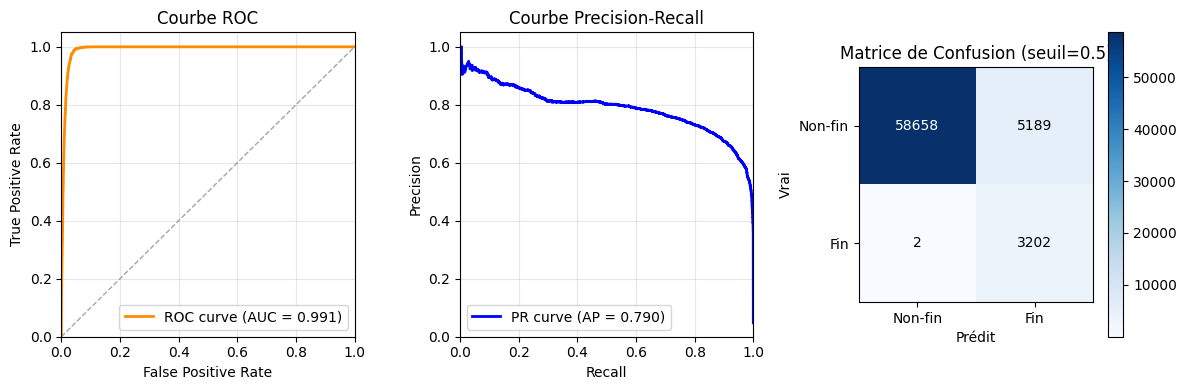

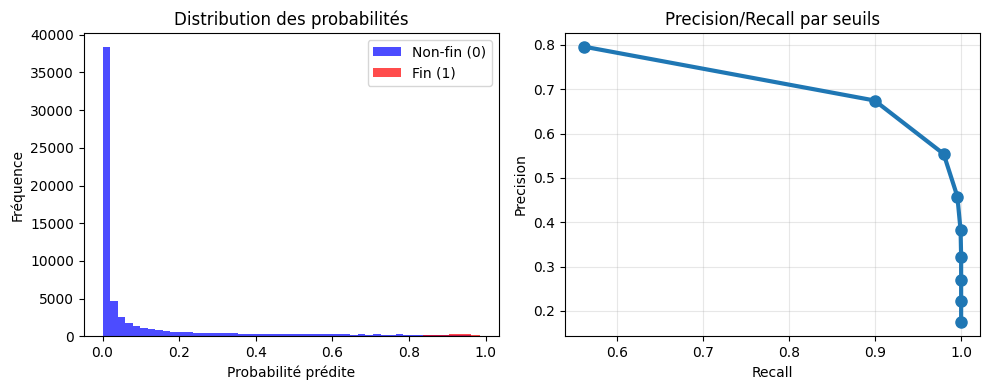

In [89]:
#MODIFIÉ
# LE
# 27 MARS




import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, roc_curve, auc, precision_recall_curve, 
    average_precision_score, confusion_matrix
)
from sklearn.preprocessing import label_binarize

# Prédictions du modèle final sur validation (dernier fold ou split manuel)
# Si tu n'as pas y_val / val_proba_20, utilise le dernier fold ou refais un split
# Pour l'exemple, on utilise model_df_train pour auto-évaluation

X_eval = model_df_train[feature_cols].copy()
y_true = model_df_train["safe_to_end_now_20km"].copy()
X_eval["airport"] = X_eval["airport"].astype("category")
if "season" in X_eval.columns:
    X_eval["season"] = X_eval["season"].astype("category")

y_proba = clf_20_final.predict_proba(X_eval)[:, 1]

# === 1. COURBE ROC ===
fpr, tpr, roc_thresholds = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# === 2. COURBE PRECISION-RECALL ===
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_proba)
pr_auc = average_precision_score(y_true, y_proba)

plt.subplot(1, 3, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

# === 3. MATRICE DE CONFUSION (seuil 0.5) ===
y_pred = (y_proba >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)

plt.subplot(1, 3, 3)
im = plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion (seuil=0.5)')
plt.colorbar(im)
plt.xticks([0, 1], ['Non-fin', 'Fin'])
plt.yticks([0, 1], ['Non-fin', 'Fin'])
plt.ylabel('Vrai')
plt.xlabel('Prédit')

# Ajouter les valeurs dans les cases
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

# === 4. HISTOGRAMME DES PROBABILITÉS ===
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y_proba[y_true == 0], bins=50, alpha=0.7, label='Non-fin (0)', color='blue')
plt.hist(y_proba[y_true == 1], bins=50, alpha=0.7, label='Fin (1)', color='red')
plt.xlabel('Probabilité prédite')
plt.ylabel('Fréquence')
plt.title('Distribution des probabilités')
plt.legend()

# === 5. PRECISION/RECALL par seuils (CORRIGÉ) ===
seuils = np.round(np.linspace(0.1, 0.9, 9), 2)
precision_list = []
recall_list = []

for seuil in seuils:
    y_pred_seuil = (y_proba >= seuil).astype(int)
    precision_list.append(precision_score(y_true, y_pred_seuil, zero_division=0))
    recall_list.append(recall_score(y_true, y_pred_seuil, zero_division=0))

df_metrics = pd.DataFrame({
    'Seuil': seuils,
    'Precision': precision_list,
    'Recall': recall_list
})

plt.subplot(1, 2, 2)
plt.plot(df_metrics['Recall'], df_metrics['Precision'], 'o-', linewidth=3, markersize=8)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision/Recall par seuils')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
X_test = model_df_test[feature_cols].copy()

X_test["airport"] = X_test["airport"].astype("category")
if "season" in X_test.columns:
    X_test["season"] = X_test["season"].astype("category")

test_proba_20 = clf_20_final.predict_proba(X_test)[:, 1]

print(test_proba_20[:10])
print("Nb prédictions:", len(test_proba_20))

[0.97123345 0.87772987 0.5845854  0.96282129 0.64674828 0.94555666
 0.9558245  0.97117697 0.96125505 0.83594212]
Nb prédictions: 170433


In [30]:
submission = model_df_test[["airport", "airport_alert_id", "date"]].copy()
submission["prediction_date"] = submission["date"]
submission["predicted_date_end_alert"] = submission["date"]
submission["confidence"] = test_pred_proba

submission = submission[
    ["airport", "airport_alert_id", "prediction_date", "predicted_date_end_alert", "confidence"]
].copy()

submission = submission.sort_values(["airport", "airport_alert_id", "prediction_date"]).reset_index(drop=True)

print(submission.head())
print(submission.shape)

   airport  airport_alert_id           prediction_date  \
0  Ajaccio             532.0 2023-01-17 07:17:34+00:00   
1  Ajaccio             533.0 2023-01-17 10:52:24+00:00   
2  Ajaccio             534.0 2023-01-17 23:47:55+00:00   
3  Ajaccio             537.0 2023-03-20 11:04:56+00:00   
4  Ajaccio             546.0 2023-05-13 21:26:58+00:00   

   predicted_date_end_alert  confidence  
0 2023-01-17 07:17:34+00:00    0.407792  
1 2023-01-17 10:52:24+00:00    0.300097  
2 2023-01-17 23:47:55+00:00    0.473217  
3 2023-03-20 11:04:56+00:00    0.525734  
4 2023-05-13 21:26:58+00:00    0.569117  
(170433, 5)


In [31]:
OUTPUT_PATH = "submission_20km_full_pipeline.csv"
submission.to_csv(OUTPUT_PATH, index=False)

print("Fichier sauvegardé :", OUTPUT_PATH)

Fichier sauvegardé : submission_20km_full_pipeline.csv
